# Week 10 - Neural Networks (solution)



Learning contents:
1. Detailed example: Two-layer MLP for regression
    - Forward pass: Calculate the values of $z_1$, $z_2$, and $y$
    - Compute the mean squared error
    - Using backpropagation, compute the gradient or the error w.r.t the weights $w^{(2)}_2$ and $w^{(1)}_{2,2}$ 
    - Compute the updated weights for $w^{(2)}_2$ and $w^{(1)}_{2,2}$ 
2. PyTorch: 2-layer MLP for classification
    - Create and train a 2-layer MLP

# 1) Detailed example: Two-layer MLP for regression
We'll be working through a forward and back-propagation example in all its details for a 2-layer MLP for regression. Our network has the following structure:

![](two-layer-nn.svg)

Where 
    $$
    z_j = \text{ReLU}\left(a_j \right)
    \qquad
    a_j = \sum_i w^{(1)}_{ij} x_i
    \qquad
    y_j = \sum_i w^{(2)}_{ij} z_i
    $$
and the biases 
    $$
    x_0 = z_0 = 1
    $$

Suppose, we have the weights
    $$
    \mathbf{W}^{(1)} = \left[ 
        \begin{matrix}
        0.1 & 0.2\\
        -1.1 & 1.2\\
        -2.1 & 2.2
        \end{matrix}
    \right]
    \qquad
    \mathbf{w}^{(2)} = \left[ 
        \begin{matrix}
        -0.1\\
        1.1 \\
        2.2
        \end{matrix}
    \right]
    $$
Notice that the bias weights are included in the weight matrix. Relating it to the drawing, we have $w_{0,1} = 0.1$, $w_{1,2} = 1.2$

Moreover, we are given an input
    $$
    \mathbf{x} = \left[ 
        \begin{matrix}
        0.1 \\
        0.2
        \end{matrix}
    \right]
    $$
    
Relating these to the drawing, we have $w^{(1)}_{1,2} = 1.2$ and $x_1 = 0.1$

## 1.1) Forward pass: Calculate the values of $z_1$, $z_2$, and $y$

In [1]:
import torch 
x = torch.tensor([
    [0.1],
    [0.2]
])

W1 = torch.tensor([
    [ 0.1, 0.2],
    [-1.1, 1.2],
    [-2.1, 2.2]
], requires_grad=True)

w2 = torch.tensor([
    [-0.1],
    [ 1.1],
    [ 2.2]
], requires_grad=True)


def augment(x):
    return torch.cat([torch.ones(1).unsqueeze(0), x])

augment(x)

tensor([[1.0000],
        [0.1000],
        [0.2000]])

In [2]:
a = W1.t().mm(augment(x))
print(f"a = {a}")

z = torch.nn.functional.relu(a)
print(f"z = {z}")

y = w2.t().mm(augment(z))
print(f"y = {y}")

a = tensor([[-0.4300],
        [ 0.7600]], grad_fn=<MmBackward0>)
z = tensor([[0.0000],
        [0.7600]], grad_fn=<ReluBackward0>)
y = tensor([[1.5720]], grad_fn=<MmBackward0>)


In conclusion, we get: 
$
    \qquad z_1 = 0.0
    \qquad z_2 = 0.76
    \qquad y = 1.572
$

## 1.2) Compute the mean squared error
Suppose our target $t=2$.
Use the formula for MSE shown in lecture 19, slide 17 (8)

In [3]:
t = torch.tensor([2])

E = 0.5 * (y - t)**2
E

tensor([[0.0916]], grad_fn=<MulBackward0>)

The error is $E = 0.0.916$

## 1.3) Using backpropagation, compute the gradient or the error w.r.t the weights $w^{(2)}_2$ and $w^{(1)}_{2,2}$ 
This corresponds to the bottom row of weights on the figure

In [4]:
dEdy = y - t # = 2*(1/2)*(t-y)**(2-1) * -1

# y = w^{(2)}_0 * 1 + w^{(2)}_1 * z_1 + + w^{(2)}_2 * z_2
dydw2_2 = z[1] # z[1] = z_2

dEdw2_2 = dEdy * dydw2_2
print(f"∂E∂w^{(2)}_1 = {dEdw2_2}")

dydz2 = w2[2]

# dReLU(a)/da is 1 because a > 0
dz2da2 = 1 

# a = w^{(1)}_0 * 1 + w^{(1)}_1 * x_1 + + w^{(1)}_2 * x_2
da2w1_22 = x[1] # x[1] = x_2

dEdw1_22 = dEdy * dydz2 * dz2da2 * da2w1_22
print(f"∂E∂w^2_1 = {dEdw1_22}")

∂E∂w^2_1 = tensor([[-0.3253]], grad_fn=<MulBackward0>)
∂E∂w^2_1 = tensor([[-0.1883]], grad_fn=<MulBackward0>)


In [5]:
# Check using PyTorch
E.backward()
print(f"∂E∂W^1 = {W1.grad}")
print(f"∂E∂w^2 = {w2.grad}")

∂E∂W^1 = tensor([[ 0.0000, -0.9416],
        [ 0.0000, -0.0942],
        [ 0.0000, -0.1883]])
∂E∂w^2 = tensor([[-0.4280],
        [ 0.0000],
        [-0.3253]])


## 1.4) Compute the updated weights for $w^{(2)}_2$ and $w^{(1)}_{2,2}$ 
Use a learning rate $\eta = 0.1$ 

In [6]:
lr = 0.1

w2_2_next = w2[2] - lr*dEdw2_2
w2_2_next

tensor([[2.2325]], grad_fn=<SubBackward0>)

In [7]:
w1_22_next = W1[2,1] - lr*dEdw1_22
w1_22_next

tensor([[2.2188]], grad_fn=<SubBackward0>)

The updated weights are thus $w^{(2)}_2 = 2.2325$ and $w^{(1)}_{2,2} = 2.2188$ 

# 2) PyTorch: 2-layer MLP for classification
Luckily, there are some nice Deep Learning libraries out there, that make working with neural networks a pleasure.
The two most noteable are [Tensorflow](https://www.tensorflow.org) and [PyTorch](https://pytorch.org). We'll be using the latter.

In order to install it in your conda environment you can use
```pip install torch torchvision```

A key feature of these libraries is that they can handle the gradient computation for you.
Moreover, they have a lot of layer types and losses, that are easily composable to handle computation of complex neural networks.

We'll be working with the classic MNIST dataset, which we can easily get via PyTorch

In [8]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_data = datasets.MNIST('../data', train=True, download=True, transform=transform)
test_data = datasets.MNIST('../data', train=False, download=True, transform=transform)

train_loader = DataLoader(
    train_data,
    batch_size = 64,
    shuffle=True,
)

test_loader = DataLoader(
    test_data,
    batch_size = 64,
)

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ../data/MNIST/raw/train-images-idx3-ubyte.gz to ../data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ../data/MNIST/raw/train-labels-idx1-ubyte.gz to ../data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ../data/MNIST/raw/t10k-images-idx3-ubyte.gz to ../data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%

Extracting ../data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ../data/MNIST/raw



A few steps happened here:
1. The dataset (train and test) was downloaded 
1. We created a `DataLoader` for each data split. Using this, we get batches of data (64 examples per batch here)
1. We told asked for the training data to be shuffled

Lets see what we get in a batch:

In [13]:
data, targets = next(iter(train_loader))
data.shape, targets.shape

(torch.Size([64, 1, 28, 28]), torch.Size([64]))

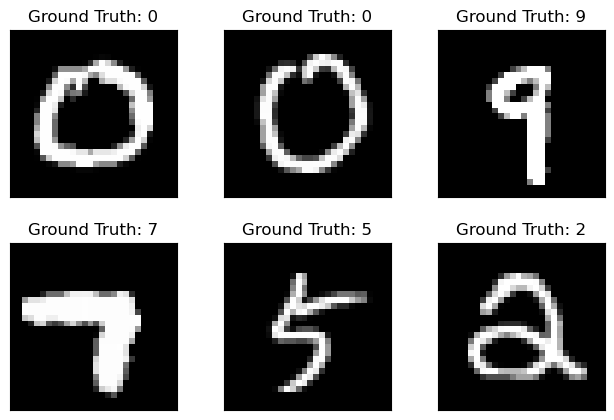

In [14]:
import matplotlib.pyplot as plt

fig = plt.figure()
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.tight_layout()
    plt.imshow(data[i][0], cmap='gray', interpolation='none')
    plt.title("Ground Truth: {}".format(targets[i]))
    plt.xticks([])
    plt.yticks([])

## 2.1) Create and train a 2-layer MLP
For the network, use a single hidden layer of 512 neurons with a ReLU activation function for the first weight Linear layer. The output of the second Linear layer should be a softmax.

For optimisation, use the SGD optimizer with learning rate of 0.001, and the negative log-likelihood loss.

Train the network for 5 epochs on the train data, and report the prediction accuracy on the test data. You should be able to get about 90% correct.

Hint: check the [PyTorch documentation](https://pytorch.org/docs/stable/index.html) for usage of the layers, optimizers and losses

In [11]:
from torch.nn import Linear, Module
from torch.nn.functional import relu, log_softmax, nll_loss
from torch.optim import SGD

class Net(Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = Linear(28*28, 512)
        self.fc2 = Linear(512, 10)

    def forward(self, x):
        x = torch.flatten(x, 1)
        x = relu(self.fc1(x))
        x = self.fc2(x)
        output = log_softmax(x, dim=1)
        return output

    
def train(
    model:Module, 
    train_loader:DataLoader, 
    optimizer: SGD, 
    epoch:int, 
    log_interval = 50
):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        # Reset the gradients
        optimizer.zero_grad() 
        
        # Feed the data through the model
        output = model(data) 
        
        # Compute the negative log-likelihood loss
        loss = nll_loss(output, target) 
        
        # Backward propagate the gradients
        loss.backward() 
        
        # Perform an update step using the optimizer
        optimizer.step() 
        
        # Log
        if batch_idx % log_interval == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))


def test(model:Module, test_loader:DataLoader):
    # Set model to evaluation mode
    model.eval()
    
    test_loss = 0
    correct = 0
    
    # Don't accumulate gradients
    with torch.no_grad():
        for data, target in test_loader:
            # Feed the data through the model
            output = model(data)
            
            # Sum up batch loss
            test_loss += nll_loss(output, target, reduction='sum').item()  
            
            # The prediction is the index of the max log-probability
            pred = output.argmax(dim=1, keepdim=True)  
            
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)

    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)
    ))

In [12]:
model = Net()
optimizer = SGD(model.parameters(), lr=0.001)

epochs = 5
for epoch in range(1, epochs + 1):
    train(model, train_loader, optimizer, epoch, log_interval=50)
    test(model, test_loader)

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.311337
Train Epoch: 1 [3200/60000 (5%)]	Loss: 2.173460
Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.067058
Train Epoch: 1 [9600/60000 (16%)]	Loss: 2.001693
Train Epoch: 1 [12800/60000 (21%)]	Loss: 1.842612
Train Epoch: 1 [16000/60000 (27%)]	Loss: 1.777094
Train Epoch: 1 [19200/60000 (32%)]	Loss: 1.622507
Train Epoch: 1 [22400/60000 (37%)]	Loss: 1.666051
Train Epoch: 1 [25600/60000 (43%)]	Loss: 1.524215
Train Epoch: 1 [28800/60000 (48%)]	Loss: 1.478056
Train Epoch: 1 [32000/60000 (53%)]	Loss: 1.325187
Train Epoch: 1 [35200/60000 (59%)]	Loss: 1.239623
Train Epoch: 1 [38400/60000 (64%)]	Loss: 1.201809
Train Epoch: 1 [41600/60000 (69%)]	Loss: 1.190662
Train Epoch: 1 [44800/60000 (75%)]	Loss: 1.179096
Train Epoch: 1 [48000/60000 (80%)]	Loss: 1.013476
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.958238
Train Epoch: 1 [54400/60000 (91%)]	Loss: 1.076769
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.893462

Test set: Average loss: 0.9148, Accuracy: 8345/10000 (83%)